# 第52课 · 「给我看证据」——Audio Core 收官：测试全绿，从零 FFT→MFCC 的真懂底气

**目标**：把 `tests/audio/` 跑到全绿，完成 Month 1 通关——**用证据证明你真懂**。

> **仪式课**：清单体——已手写哪些模块、测试如何钉住行为。**勿倾倒新概念**；模糊处回对应 L 补洞。

🔗 Aurora 连接：
- `src/aurora/audio/io.py` — WAV 读写
- `src/aurora/audio/windows.py` — Hann / Hamming
- `src/aurora/audio/transforms.py` — DFT / FFT / IFFT / RFFT
- `src/aurora/audio/stft.py` — 分帧（framing） + 短时傅里叶变换
- `src/aurora/audio/mel.py` — Hz↔Mel 转换、mel 滤波器组、mel 频谱
- `src/aurora/audio/mfcc.py` — DCT-II、MFCC

← **上一课**　[L51 · MFCC 工程实战](L51_real_audio.ipynb)

> 上节课学习了 **MFCC 工程实战**：在真实 WAV 音频上提取特征，librosa 对答案。  
> 本课将探讨 **Audio Core 完结**。

## 本课剧情：怎么证明你"真的写了"FFT？

当有人追问（面试、同事，或未来的自己）："你说你从零实现了 FFT 和 MFCC——给我看证据。"

这个问题有两层：
1. **代码层**：测试套件能覆盖边界情况、数值精度、形状正确性吗？
2. **理解层**：不看代码，能白板推导完整公式链吗？

本节是 Audio Core 的收口仪式：把 `tests/audio/` 的 39 个测试跑到全绿，再把你"真懂"的证据整理成面试能讲清的几条。

**从 WAV 到 MFCC 的完整公式链**（6 步记忆法）：

```
x[n]  → STFT: X[t,k] = Σ x[t·hop+n]·w[n]·e^{-2πikn/N}
     → power: P[t,k] = |X[t,k]|²
     → Mel: M[t,m] = Σ_k P[t,k]·H_m[k]        (三角滤波器)
     → log: L[t,m] = log(M[t,m] + ε)
     → DCT: C[t,c] = Σ_m L[t,m]·cos(π·c·(2m+1)/(2N))·w(c)
     → 截断: MFCC[t, :n_mfcc]
```

**测试套件的三种断言类型**：

| 断言类型 | 示例 | 意义 |
|---|---|---|
| Shape | `assert S.shape == (n_frames, n_bins)` | 维度正确 |
| Numerical | `np.allclose(my_fft, np.fft.fft, atol=1e-10)` | 数值精度 |
| Property | `assert X[N-k] == conj(X[k])` | 数学性质 |

本节目标：`make test` 零失败，同时把 5 个关键公式整理成你能随时白板推导、当场讲清的版本。

In [1]:
# Aurora matplotlib bootstrap
from pathlib import Path
import sys

_root = None
_cwd = Path.cwd().resolve()
for _candidate in (_cwd, *_cwd.parents):
    if (_candidate / '_matplotlib_bootstrap.py').exists():
        _root = _candidate
        break
if _root is None:
    _notebooks_dir = _cwd / 'notebooks'
    if _notebooks_dir.exists():
        for _found in _notebooks_dir.rglob('_matplotlib_bootstrap.py'):
            _root = _found.parent
            break
if _root is not None and str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

from _matplotlib_bootstrap import apply as _aurora_mpl_apply
_aurora_mpl_apply()


In [2]:
import subprocess
import numpy as np

## 1. 从信号到特征的完整管线

```
WAV → 分帧(frame_signal) → 加窗（windowing）(hann/hamming) → FFT(rfft)
    → |·|² → mel 滤波(mel_filterbank) → log → DCT-II → MFCC
```

每一步的数学形式：

- **分帧**：把长为 `T` 的信号切成长 `N`、步长 `H` 的帧。不填充时共 `1 + (T-N)//H` 帧；aurora 默认 `center=True`（先在两端各反射填充 `N//2`），帧数变为 `1 + T//H`。
- **加窗**：逐元素乘以 `w[n] = 0.5 * (1 - cos(2π n / N))`（Hann 周期窗）。
- **RFFT**：`X[k] = sum_{n=0}^{N-1} x[n] * e^{-j 2π k n / N}`，保留 `N//2+1` 个非冗余频点。
- **Mel 滤波**：`M[m] = sum_k fb[m,k] * |X[k]|²`，三角滤波器组（triangular filter bank），`fb` 形状 `(n_mels, N//2+1)`。
- **对数压缩（log compression）**：`log_mel = 10 * log10(M + eps)`，模拟人耳响度感知的对数特性。
- **DCT-II（正交归一化）**：`C[i] = scale[i] * sum_m log_mel[m] * cos(π/M * (m+0.5) * i)`，前 13 个系数即 MFCC。

### 关键概念深入：为什么这 6 步能从声音中提出特征？

#### 🔑 概念 1：RFFT 与共轭对称性——为什么频率维是 N//2+1？

你可能会问："既然信号是实数，为什么 FFT 输出还是复数？" 

**直观解释**：傅里叶变换问的是"这段信号里包含多少频率 f 的成分？"。要用数学回答这个问题，就需要用**复数**来同时描述两件事：
- **幅度**（magnitude）：该频率的强度
- **相位**（phase）：该频率的波形相对于参考时间的偏移

这两个信息合在一起，用复数 $X[k] = A[k] \cdot e^{j\phi[k]}$ 表示（其中 $j = \sqrt{-1}$ 是虚数单位，音频工程用 $j$ 而不是 $i$ 只是习惯约定）。

**对称性的妙处**：当输入信号是实数时（比如麦克风录音），FFT 的输出有一个特殊的性质：
$$X[N-k] = \text{conj}(X[k])$$
即"镜像频率"的复数是共轭的。这意味着：
- 第 0 到 N//2 个频率完全确定了整个频谱
- 第 N//2+1 到 N-1 个频率只是前面的重复信息

所以 **RFFT**（Real FFT）只保留前 N//2+1 个点，避免浪费一半的计算和存储空间。

**看个数字例子**：N=8 时，
```
DFT    输出 8 个复数：[X₀, X₁, X₂, X₃, X₄, X₅, X₆, X₇]
RFFT   输出 5 个复数：[X₀, X₁, X₂, X₃, X₄]  ← 因为 8//2+1=5
      后面 3 个可由对称性恢复：X₅=conj(X₃), X₆=conj(X₂), X₇=conj(X₁)
```

#### 🔑 概念 2：复数和欧拉公式——为什么频率能用 $e^{-j2\pi kn/N}$ 表示？

DFT 公式写得很吓人：
$$X[k] = \sum_{n=0}^{N-1} x[n] \cdot e^{-j 2\pi k n / N}$$

但其实它就是在回答："有多少频率 k 的正弦波分量？"

**欧拉恒等式**告诉我们：
$$e^{j\theta} = \cos\theta + j\sin\theta$$

所以：
$$e^{-j2\pi kn/N} = \cos(2\pi kn/N) - j\sin(2\pi kn/N)$$

这意味着 DFT 实际上在**同时做两件事**：
- 用 $\cos$ 提取余弦波的幅度
- 用 $\sin$ 提取正弦波的幅度（相位差）

最后两个幅度合在一起形成一个复数，既记录了强度，也记录了相位。这就是为什么"用复数表示频率"是最简洁的办法。

#### 🔑 概念 3：Mel 滤波器三角形——为什么要转到 mel 域再转回来？

目前为止，我们得到的是 **Hz 域频谱**（均匀间隔的频率轴）。但人耳对频率的感知不是线性的：
- 100-200 Hz 的差异我们能清晰分辨
- 10,000-10,100 Hz 的差异我们就听不太出来

**Mel 刻度**是为了模拟人耳的对数感知。转换公式是（HTK 标准，aurora 默认用这个）：
$$\text{mel}(f) = 2595 \log_{10}(1 + f/700)$$

**Mel 滤波器构造的三步流程**：

1. **在 Mel 域均匀取中心点**  
   比如要 40 个滤波器，在 mel 域均匀取 40 个点：$\text{mel}_{\min}, \text{mel}_{\min}+\Delta, \text{mel}_{\min}+2\Delta, ..., \text{mel}_{\max}$

2. **反变换回 Hz 域**  
   用逆公式把这 40 个 mel 点变回 Hz：
   $$f = 700 \cdot (10^{\text{mel}/2595} - 1)$$
   这样在 Hz 域就不均匀了——低频紧密，高频稀疏。

3. **构造三角形**  
   每个滤波器是一个三角形波：
   - 左斜坡：从 0 斜升到峰值 1（在中心点）
   - 右斜坡：从 1 斜降回 0（在右邻域中心点）
   
   用公式表示滤波器 m：
   $$H_m[k] = \begin{cases}
   0 & \text{if } k < f_m^{\text{left}} \\
   \frac{k - f_m^{\text{left}}}{f_m^{\text{center}} - f_m^{\text{left}}} & \text{if } f_m^{\text{left}} \le k < f_m^{\text{center}} \\
   \frac{f_m^{\text{right}} - k}{f_m^{\text{right}} - f_m^{\text{center}}} & \text{if } f_m^{\text{center}} \le k < f_m^{\text{right}} \\
   0 & \text{if } k \ge f_m^{\text{right}}
   \end{cases}$$
   
   其中 $f_m^{\text{left}}, f_m^{\text{center}}, f_m^{\text{right}}$ 是三个顶点的频率。

最后得到 `(n_mels, n_fft//2+1)` 的矩阵 `fb`，每一行是一个三角形滤波器。

#### 🔑 概念 4：DCT 的正交归一化——为什么是 sqrt(2/N)？

DCT-II 的基本公式是：
$$C[i] = \sum_{m=0}^{M-1} x[m] \cdot \cos\left(\frac{\pi}{M}(m+0.5) i\right)$$

但这样算出的矩阵不是"正交"的。什么是正交矩阵？

**正交矩阵**满足 $D \cdot D^T = I$（单位矩阵）。好处是什么？
- 能量守恒：如果信号 $x$ 经过 DCT 变换得到 $c$，那么 $\|x\|^2 = \|c\|^2$（帕塞瓦尔定理）
- 可逆性好：逆变换非常稳定，不容易放大误差
- 独立分解：DCT 系数之间相互独立，便于后续机器学习

要让矩阵正交，需要加权：
$$D_{\text{orthonormal}}[i,m] = \sqrt{\frac{2}{M}} \cdot \cos\left(\frac{\pi}{M}(m+0.5) i\right) \quad (i > 0)$$
$$D_{\text{orthonormal}}[0,m] = \sqrt{\frac{1}{M}} \cdot \cos\left(\frac{\pi}{M}(m+0.5) \cdot 0\right) = \sqrt{\frac{1}{M}}$$

**为什么首项特殊？** 因为 $\cos(0) = 1$，如果也乘以 $\sqrt{2/M}$，第一个基向量的能量会是其他的 2 倍，破坏正交性。所以首项用 $\sqrt{1/M}$。

#### 🔑 概念 5：分帧和 center 填充——为什么帧数从 1+(T-N)//H 变成 1+T//H？

不填充时，从长为 T 的信号切 N 长的帧，步长 H：
- 第 0 帧：位置 0 到 N-1
- 第 1 帧：位置 H 到 H+N-1
- ...
- 第 m 帧：位置 m·H 到 m·H+N-1（最后一帧要 m·H+N-1 < T）

解这个不等式：$m \le \frac{T-N}{H}$，所以最多 $m_{\max} = \lfloor(T-N)/H\rfloor$，总帧数 = $m_{\max}+1 = 1 + \lfloor(T-N)/H\rfloor$。

**加上 center 填充**（两端各补 N//2 个样本）：
- 填充后信号长变成 $T + 2 \cdot (N//2) \approx T + N$（假设 N 是偶数）
- 新的帧数 = $1 + \lfloor(T+N-N)/H\rfloor = 1 + \lfloor T/H \rfloor$

**为什么要填充？** 确保首尾的信号段也能被完整的窗函数处理，不会因为窗的两端是 0 就浪费信息。

**数字例子**：sr=16000, dur=1s, n_fft=1024, hop=256
- T = 16000（样本数）
- 不填充：$n_{\text{frames}} = 1 + \lfloor(16000-1024)/256\rfloor = 1 + 58 = 59$
- 填充（center=True）：$n_{\text{frames}} = 1 + \lfloor 16000/256 \rfloor = 1 + 62 = 63$

**"反射填充"到底怎么"折"？——光说"镜像"还不够精确**

到这里你可能还有一个疑问：填充的 `N//2` 个新样本，具体值是多少？"反射"听起来像是把信号末端对着镜子照一下，但镜子该架在哪根线上，藏着一个容易分歧的细节——**要不要把边界那个点也一起复制进去？**

打个比方：把一条纸带的末端往回折，贴在桌上。你可以选择"折痕正好压在最后一个点上"（这个点会跟自己的镜像贴在一起，出现两份），也可以选择"折痕压在最后一个点和倒数第二个点的正中间"（最后一个点只出现一次，它自己就是镜子）。NumPy 用两个不同的名字区分这两种折法：

- `mode='symmetric'`（折痕压在点上，边界点被复制一次）
- `mode='reflect'`（折痕压在两点之间，边界点本身不重复，只出现一次）

用一个具体例子看清楚：信号 `x = [a, b, c, d, e, f, g, h]`（8 个点），在左端填充 4 个点：

| 模式 | 结果（左边新增的 4 个点 + 原信号） |
|---|---|
| `mode='symmetric'` | `[d, c, b, a,  a, b, c, d, e, f, g, h]` —— 把 `a,b,c,d` 整体翻过去，**a 自己也被复制了一份** |
| `mode='reflect'` | `[e, d, c, b,  a, b, c, d, e, f, g, h]` —— 把 `b,c,d,e` 沿着 `a` 翻过去，**a 本身只出现一次**（它就是"折痕"所在的镜子） |

（如果你在日志里猜的是 `[e,d,c,b,a,b,c,d,...]`——恭喜，这正是 `reflect` 的答案！）

**aurora 用的是哪一种？** 直接看源码 `src/aurora/audio/stft.py` 里那一行就知道：
```python
signal = np.pad(signal, pad, mode="reflect")
```
是 `reflect`，不是 `symmetric`。右端同理：把倒数第二到倒数第五个点（`d,e,f,g`）沿着最后一个点 `h` 翻过去接在信号后面。

下面这格代码直接跑一下 NumPy 的两种模式，把真实输出打印出来对照——比死记规则更可靠，也顺便去读一眼 aurora 源码里那一行代码，确认它确实用的是 `reflect`。

In [3]:
# 老陈的问题：反射填充到底怎么"折"？用字母数组把顺序看得明明白白
x_letters = np.array(list("abcdefgh"))
print("原始信号：                          ", x_letters)
print("mode='reflect'  （aurora 用的这种）：", np.pad(x_letters, 4, mode='reflect'))
print("mode='symmetric'（边界点会重复）    ：", np.pad(x_letters, 4, mode='symmetric'))

# 直接读 aurora 源码，确认它真的用 reflect，不是凭空猜
import inspect
from aurora.audio.stft import frame_signal

pad_line = [
    line.strip()
    for line in inspect.getsource(frame_signal).splitlines()
    if "np.pad" in line and "mode" in line
][0]
print(f"\naurora stft.py 源码里真正调用的那一行：{pad_line}")
assert 'mode="reflect"' in pad_line
print("✅ 确认：aurora 的 center 填充用的是 reflect，不是 symmetric")

# 换成数字信号再验证一遍，规律完全一样，只是数字比字母更容易心算折叠位置
x_num = np.arange(1, 9)  # [1,2,3,4,5,6,7,8]
padded = np.pad(x_num, 4, mode='reflect')
print(f"\n数字版验证：{x_num} 反射填充4 → {padded}")
print("左边新增的 [5,4,3,2] 是把 2,3,4,5 沿着端点 1 翻过去（1 本身不重复）；")
print("右边新增的 [7,6,5,4] 是把 4,5,6,7 沿着端点 8 翻过去（8 本身不重复）——")
print("这正是 frame_signal(center=True) 在两端各填充 N//2 个样本时用的规则。")

原始信号：                           ['a' 'b' 'c' 'd' 'e' 'f' 'g' 'h']
mode='reflect'  （aurora 用的这种）： ['e' 'd' 'c' 'b' 'a' 'b' 'c' 'd' 'e' 'f' 'g' 'h' 'g' 'f' 'e' 'd']
mode='symmetric'（边界点会重复）    ： ['d' 'c' 'b' 'a' 'a' 'b' 'c' 'd' 'e' 'f' 'g' 'h' 'h' 'g' 'f' 'e']

aurora stft.py 源码里真正调用的那一行：signal = np.pad(signal, pad, mode="reflect")
✅ 确认：aurora 的 center 填充用的是 reflect，不是 symmetric

数字版验证：[1 2 3 4 5 6 7 8] 反射填充4 → [5 4 3 2 1 2 3 4 5 6 7 8 7 6 5 4]
左边新增的 [5,4,3,2] 是把 2,3,4,5 沿着端点 1 翻过去（1 本身不重复）；
右边新增的 [7,6,5,4] 是把 4,5,6,7 沿着端点 8 翻过去（8 本身不重复）——
这正是 frame_signal(center=True) 在两端各填充 N//2 个样本时用的规则。


In [4]:
from aurora.audio import sine, stft, mel_spectrogram, mfcc

sr = 16000
x = sine(440.0, 1.0, sr)          # 1 秒 440 Hz 纯音

S = stft(x, n_fft=1024, hop_length=256)          # (n_frames, 513) complex
M = mel_spectrogram(x, sr, n_fft=1024, hop_length=256, n_mels=80)  # (n_frames, 80)
C = mfcc(x, sr, n_mfcc=13, n_fft=1024, hop_length=256)             # (n_frames, 13)

print(f"STFT  shape: {S.shape}  dtype: {S.dtype}")
print(f"Mel   shape: {M.shape}  dtype: {M.dtype}")
print(f"MFCC  shape: {C.shape}  dtype: {C.dtype}")
print(f"MFCC[0, :5] = {C[0, :5].round(4)}")
assert np.iscomplexobj(S)
assert M.shape[1] == 80
assert C.shape[1] == 13
print("✅ 管线形状全部正确")

STFT  shape: (63, 513)  dtype: complex128
Mel   shape: (63, 80)  dtype: float64
MFCC  shape: (63, 13)  dtype: float64
MFCC[0, :5] = [ 77.8283 128.4779  16.1336  -7.8905 -20.2755]
✅ 管线形状全部正确


In [5]:
# 数值验证：Mel 滤波器三角形构造的具体例子
from aurora.audio.mel import hz_to_mel, mel_to_hz, mel_filterbank

# 例子：3 个 Mel 滤波器，n_fft=256（较小的值便于理解）
n_mels, n_fft, sr = 3, 256, 16000
fb_demo = mel_filterbank(n_mels=n_mels, n_fft=n_fft, sample_rate=sr)

n_freqs = n_fft // 2 + 1  # 129 个频率点
freq_hz = np.linspace(0, sr//2, n_freqs)  # 0, 62.5, 125, ..., 8000 Hz

print(f"Mel 滤波器构造演示（n_mels={n_mels}, n_fft={n_fft}）")
print(f"频率点总数：{n_freqs}，范围：0 ~ {sr//2} Hz\n")

# 找出每个滤波器的三个顶点（非零范围）
for m in range(n_mels):
    nonzero_idx = np.where(fb_demo[m] > 0)[0]
    if len(nonzero_idx) > 0:
        left_idx, right_idx = nonzero_idx[0], nonzero_idx[-1]
        # 找峰值（最大值）
        peak_idx = np.argmax(fb_demo[m])
        
        left_hz = freq_hz[left_idx]
        peak_hz = freq_hz[peak_idx]
        right_hz = freq_hz[right_idx]
        
        left_mel = hz_to_mel(left_hz) if left_hz > 0 else 0
        peak_mel = hz_to_mel(peak_hz)
        right_mel = hz_to_mel(right_hz)
        
        print(f"滤波器 {m}：")
        print(f"  Hz 域顶点：{left_hz:.1f} Hz → {peak_hz:.1f} Hz（峰值）→ {right_hz:.1f} Hz")
        print(f"  Mel 域顶点：{left_mel:.1f} mel → {peak_mel:.1f} mel → {right_mel:.1f} mel")
        print(f"  观察：Mel 域接近均匀间隔，Hz 域低频密集、高频稀疏 ✓\n")

# 验证RFFT 对称性（实数信号）
x_real = np.sin(2 * np.pi * 440 * np.arange(1024) / 16000)
X_rfft = np.fft.rfft(x_real)
print(f"\n✅ RFFT 对称性验证（N=1024）：")
print(f"  RFFT 输出长度：{len(X_rfft)} = 1024//2+1")
print(f"  输入信号类型：real（实数）")
print(f"  输出类型：complex（复数）✓")

Mel 滤波器构造演示（n_mels=3, n_fft=256）
频率点总数：129，范围：0 ~ 8000 Hz

滤波器 0：
  Hz 域顶点：62.5 Hz → 625.0 Hz（峰值）→ 1750.0 Hz
  Mel 域顶点：96.4 mel → 719.1 mel → 1411.9 mel
  观察：Mel 域接近均匀间隔，Hz 域低频密集、高频稀疏 ✓

滤波器 1：
  Hz 域顶点：625.0 Hz → 1750.0 Hz（峰值）→ 3875.0 Hz
  Mel 域顶点：719.1 mel → 1411.9 mel → 2115.7 mel
  观察：Mel 域接近均匀间隔，Hz 域低频密集、高频稀疏 ✓

滤波器 2：
  Hz 域顶点：1812.5 Hz → 3937.5 Hz（峰值）→ 8000.0 Hz
  Mel 域顶点：1440.2 mel → 2131.0 mel → 2840.0 mel
  观察：Mel 域接近均匀间隔，Hz 域低频密集、高频稀疏 ✓


✅ RFFT 对称性验证（N=1024）：
  RFFT 输出长度：513 = 1024//2+1
  输入信号类型：real（实数）
  输出类型：complex（复数）✓


## 2. 测试套件验证

`tests/audio/` 下有两个测试文件：

| 文件 | 覆盖范围 | 关键断言 |
|------|----------|----------|
| `test_transforms.py` | DFT / FFT / IFFT / RFFT | `atol=1e-9` 对比 `numpy.fft` |
| `test_features.py` | windows / STFT / mel / WAV I/O | `atol=1e-12` 窗函数（window function） / DCT-II |
| `test_features.py` (MFCC) | MFCC shape only | 仅形状断言 `C.shape[1] == 13`，**暂无数值 atol 测试** |

关键测试点举例：

```python
# FFT 和 NumPy 逐元素一致
np.testing.assert_allclose(T.fft(x), np.fft.fft(x), atol=1e-9)

# DCT-II 手动公式
basis = np.cos(np.pi / n * np.outer(k, k + 0.5))
ref = x @ basis.T * scale
np.testing.assert_allclose(dct_ii(x), ref, atol=1e-12)

# Hann 窗与 numpy.hanning 一致（对称模式）
np.testing.assert_allclose(hann(64, periodic=False), np.hanning(64), atol=1e-12)
```

这些测试的设计原则：每个函数都有一个独立于实现的参考答案（公式或 NumPy），只要数学正确就一定通过。

In [6]:
import sys
from pathlib import Path

result = subprocess.run(
    [sys.executable, "-m", "pytest", "tests/audio/", "-v", "--tb=short", "--no-header"],
    capture_output=True, text=True,
    cwd=subprocess.check_output(["git", "rev-parse", "--show-toplevel"], text=True).strip(),  # aurora repo root
)
print(result.stdout[-4000:] if len(result.stdout) > 4000 else result.stdout)
if result.returncode != 0:
    print(result.stderr[-2000:])
assert result.returncode == 0, "❌ 有测试失败，请检查上方输出"
print("✅ tests/audio/ 全部通过")

============================= test session starts ==============================
collected 39 items

tests/audio/test_features.py ..............                              [ 35%]
tests/audio/test_transforms.py .........................                 [100%]

============================== 39 passed in 0.81s ==============================

✅ tests/audio/ 全部通过


## 3. Month 1 交付标准

通关的三层验证：

**层1 — 代码能跑**：`make test` 零失败，`make demo` 输出正确频谱图。

**层2 — 数学能说清**：能对着空白文件重写任意一个函数。逐行对应公式，不依赖记忆：
- `dct_ii`：`basis[k, m] = cos(π/N * (m+0.5) * k)`，正交归一化系数 `sqrt(2/N)`，首项 `sqrt(1/N)`。
- `mel_filterbank`：三角滤波器顶点坐标在 mel 域均匀分布，转换回 Hz 后不均匀。
- `fft`：Cooley-Tukey 蝶形分解，`N=2^k` 时将 `O(N²)` 降为 `O(N log N)`。

**层3 — 能对比差异**：能解释 aurora 和 librosa 输出微小不同的原因（归一化策略、mel 刻度参数、中心填充行为）。

```
检查清单
[ ] pytest tests/audio/  →  全绿
[ ] 能手写 dct_ii(x)，解释每行
[ ] 能手写 mel_filterbank(n_mels, n_fft, sr)，解释三角形顶点坐标
[ ] 能解释 hann(N, periodic=True) 和 periodic=False 的区别
[ ] 能说出 stft 输出形状 (n_frames, N//2+1) 的来由
```

In [7]:
from aurora.audio import (
    sine, hann, hamming, dct_ii, mel_filterbank,
    frame_signal, stft, mel_spectrogram, mfcc,
    hz_to_mel, mel_to_hz, read_wav, write_wav
)

# 检查1：DCT-II 手动验证
x_test = np.array([1.0, 2.0, 3.0, 4.0])
n = len(x_test)
k = np.arange(n)
basis = np.cos(np.pi / n * np.outer(k, k + 0.5))
scale = np.full(n, np.sqrt(2.0 / n)); scale[0] = np.sqrt(1.0 / n)
ref_dct = x_test @ basis.T * scale
np.testing.assert_allclose(dct_ii(x_test), ref_dct, atol=1e-12)
print("✅ DCT-II 手动公式验证通过")

# 检查2：mel 滤波器组形状和非负性
fb = mel_filterbank(n_mels=40, n_fft=1024, sample_rate=16000)
assert fb.shape == (40, 513) and np.all(fb >= 0.0)
print(f"✅ mel_filterbank shape={fb.shape}, 全非负, 各行峰值 > 0: {np.all(fb.max(axis=1) > 0)}")

# 检查3：Hann 窗周期/对称
per = hann(8, periodic=True)
sym = hann(9, periodic=False)
np.testing.assert_allclose(per, sym[:-1], atol=1e-12)
print("✅ hann periodic=True 等于 symmetric N+1 去掉最后一点")

# 检查4：STFT 形状
x_1s = sine(440.0, 1.0, 16000)
S = stft(x_1s, n_fft=1024, hop_length=256)
assert S.shape[1] == 1024 // 2 + 1
print(f"✅ stft 输出 {S.shape}，频率维 = N//2+1 = {1024//2+1}")

# 检查5：mel 转换可逆
freqs = np.array([0.0, 100.0, 440.0, 1000.0, 8000.0])
np.testing.assert_allclose(mel_to_hz(hz_to_mel(freqs)), freqs, atol=1e-6)
print("✅ hz_to_mel → mel_to_hz 往返误差 < 1e-6 Hz")

✅ DCT-II 手动公式验证通过
✅ mel_filterbank shape=(40, 513), 全非负, 各行峰值 > 0: True
✅ hann periodic=True 等于 symmetric N+1 去掉最后一点
✅ stft 输出 (63, 513)，频率维 = N//2+1 = 513
✅ hz_to_mel → mel_to_hz 往返误差 < 1e-6 Hz


## 参数实验：aurora.mfcc vs librosa.feature.mfcc

**参数**：`n_fft=1024, hop_length=256, n_mels=80, n_mfcc=13`，信号为 1 秒 440 Hz 纯音。

**预期现象**：
- 形状相同 `(n_frames, 13)`（两者默认都 `center=True`，帧数一致），数值相近但不完全一致。
- 主要差异来源：
  1. mel 刻度与归一化：aurora 用 HTK 公式 `2595 * log10(1 + f/700)` 且三角滤波器不归一化；librosa 默认 **Slaney** 刻度（`htk=False`）加 `norm="slaney"` 面积归一化——这是数值差异的主要来源。
  2. 填充模式：都在首尾各填充 `n_fft//2`，但 aurora 用反射填充，librosa 新版默认零填充，只影响首尾几帧。
  3. power 参数：librosa 默认对功率谱（power spectrum，`|X|²`）建 mel，aurora `mel_spectrogram` 同样是功率谱，这一点一致。

运行下方 code 格，观察 RMSE 数量级和第 0 帧差异。

## 常见困惑 FAQ

### Q1: "对数压缩" 加 eps 是什么意思？为什么 M[t,m] 里可能有 0？

**问题**：代码说 `log_mel = 10 * log10(M + eps)`，为什么要加 eps？ M 有 0 值吗？

**回答**：是的，M 可能有 0。原因很简单——Mel 频谱 `M[t,m] = sum_k P[t,k] * H_m[k]`，如果某个 mel 频率段在某一帧完全没有能量（比如那段声音太安静），M[t,m] 就是 0。

然后你对 0 取对数：`log10(0) = -∞`，数值爆炸了。所以必须先加一个很小的正数 eps（通常 1e-10），变成 `log10(eps)` ≈ -10，一个有限的大负数，便于后续处理。

这种处理方法叫 **动态范围压缩**——用对数把很大的数值范围（1e8 到 1）压缩成易处理的范围（80 到 0）。

### Q2: `np.outer()` 是什么？怎么和矩阵乘法关系？

**问题**：DCT 验证代码用 `basis = np.cos(np.pi * np.outer(k, 2*n_arr+1) / (2*N_dct))`，np.outer() 是什么？

**回答**：`np.outer(a, b)` 计算两个 1D 数组的外积（outer product）。

```python
a = np.array([1, 2, 3])        # shape (3,)
b = np.array([10, 20])         # shape (2,)
np.outer(a, b) = [
  [1*10,  1*20],
  [2*10,  2*20],
  [3*10,  3*20]
]  # shape (3, 2)
```

**这和矩阵乘法的关系**：如果 a 是列向量（shape (m,1)），b 是行向量（shape (1,n)），那么 `a @ b` 就等于 `np.outer(a, b)`。

在 DCT 中，我们要计算每个基向量 k 和每个输入点 n 的乘积，形成一个 2D 矩阵。`np.outer()` 是最简洁的写法。

### Q3: Hann 窗的"周期"vs"对称"——什么时候用哪个？

**问题**：代码说 `hann(8, periodic=True) ≈ hann(9, periodic=False)[:-1]`，这两个什么区别？

**回答**：两种窗的公式是：
- **对称窗**（symmetric）：$w[n] = 0.5 \cdot (1 - \cos(2\pi n / (N-1)))$，N 是窗长，两端对称地都接近 0
- **周期窗**（periodic）：$w[n] = 0.5 \cdot (1 - \cos(2\pi n / N))$，N 作为周期

数学上，`hann(8, periodic=True)` 等于把 `hann(9, periodic=False)` 的前 8 个点取出来。

**什么时候用哪个？**
- **STFT 用周期窗**（`periodic=True`）：STFT 的帧是滑动的，连续帧之间有 50% 重叠（通常 hop=N/4）。周期窗在帧交接处能保持"能量守恒"（叫 COLA 条件），不会有音频丢失或跳跃。
- **FFT 单次分析用对称窗**（`periodic=False`）：一次性 FFT 一段信号，对称窗的数学性质更好。

Aurora STFT 默认用 `periodic=True`，确保重叠帧的能量正确合并。

### Q4: Slaney vs HTK——librosa 和 aurora 为什么不一样？

**问题**：代码说 aurora 用 HTK，librosa 默认 Slaney，这是什么？

**回答**：这是两个不同的 Mel 刻度标准，由不同研究机构定义：

| 标准 | mel 公式 | 归一化 | 用处 |
|------|----------|--------|------|
| **HTK** | `2595 * log10(1 + f/700)` | 不归一化 | 学术和语音识别 |
| **Slaney** | `2595 * log10(1 + f/700)`（公式一样）| **面积归一化** | librosa 默认 |

关键差异是**面积归一化**。什么意思？

三角滤波器的面积（∫ H[f] df）本来因为频率间隔不同而不一样。Slaney 标准会对每个滤波器的系数加权，使得所有滤波器的面积都相等。这样做的好处是：不同频率段的声学特征被"公平对待"。

**在工程中的影响**：
- 用 HTK（aurora）：mel 频谱会显得高频更强
- 用 Slaney（librosa）：mel 频谱在全频范围更均衡

选择哪个？如果和论文对标，看论文用什么。如果是自己的项目，Slaney 的数值平衡性更好。

### Q5: 为什么最后只取前 13 个 MFCC 系数？

**问题**：DCT 输出 M 维（M = mel 滤波器数，通常 40），但只用前 13 个，为什么？

**回答**：这是个**工程约定**，有历史背景：

1. **能量衰减**：DCT 的后面系数代表 mel 频谱的高频细节。对于语音识别任务，这些细节噪声多、信号少，不划算。
2. **研究发现**：1980 年代语音识别研究发现，前 12~13 个 MFCC 系数就能捕捉 95% 以上的识别信息。
3. **标准化**：后来变成了行业标准，大多数音频系统都用 13（或 13+1 差分 = 26）。

现代深度学习有时会用更多（比如 40），因为神经网络能更好地利用高频信息。但在传统系统中，13 是最经济的选择。

### Q6: 为什么测试用 `atol=1e-9` 而不是完全精确？

**问题**：test_transforms.py 说 `atol=1e-9`，为什么不能是 0？

**回答**：浮点数的精度有限。计算机用 64-bit 浮点（双精度），机器精度约 2.22e-16。

一个 FFT 要做 N·log₂(N) 次乘加运算。每次运算都有舍入误差，误差会累积：
- N=1024 时，log₂(N)=10，操作数 ≈ 10240
- 累积误差 ≈ 2.22e-16 × 10240 ≈ 2.3e-12

所以设定 `atol=1e-9` 给了足够的"容差"，既能检测出真正的 bug（比如公式写错），又不会因为浮点舍入就失败。

如果 atol 设得太严（比如 1e-15），即使代码完全正确也会因为舍入误差而失败；如果太松（比如 1e-6），真正的 bug 就漏过了。

In [8]:
try:
    import librosa
    HAS_LIBROSA = True
except ImportError:
    HAS_LIBROSA = False
    print("librosa 未安装，跳过对比（pip install librosa 后重试）")

if HAS_LIBROSA:
    from aurora.audio import sine, mfcc as aurora_mfcc

    sr = 16000
    x = sine(440.0, 1.0, sr).astype(np.float32)

    # aurora（center=True，反射填充）
    C_aurora = aurora_mfcc(x.astype(np.float64), sr,
                           n_mfcc=13, n_fft=1024, hop_length=256, n_mels=80)

    # librosa（center=True，默认零填充）
    C_lib_center = librosa.feature.mfcc(
        y=x, sr=sr, n_mfcc=13, n_fft=1024, hop_length=256, n_mels=80
    ).T  # librosa 返回 (n_mfcc, n_frames), 转置为 (n_frames, n_mfcc)

    print(f"aurora  MFCC shape: {C_aurora.shape}")
    print(f"librosa MFCC shape: {C_lib_center.shape}")

    # 对齐帧数后比较
    n_common = min(C_aurora.shape[0], C_lib_center.shape[0])
    rmse = np.sqrt(np.mean((C_aurora[:n_common] - C_lib_center[:n_common])**2))
    print(f"前 {n_common} 帧 RMSE = {rmse:.4f}")
    print(f"aurora  第0帧前5系数: {C_aurora[0, :5].round(3)}")
    print(f"librosa 第0帧前5系数: {C_lib_center[0, :5].round(3)}")
    print()
    print("差异来源分析：")
    print(f"  帧数差 = {C_lib_center.shape[0] - C_aurora.shape[0]}（两者都 center=True，应为 0）")
    print("  数值差异主要来自 mel 刻度：aurora 用 HTK 且不归一化，librosa 默认 Slaney + norm='slaney'")

librosa 未安装，跳过对比（pip install librosa 后重试）


## 附录 · Audio Core 结业：你已具备的能力清单

- [ ] 能从空白重写 `fft` / `stft` / `mel_filterbank` / `mfcc`（口述 + 白板）
- [ ] `make test` audio 全绿
- [ ] 能解释 MFCC 五段 shape：`(T, n_mels)` → `(T, 13)`
- [ ] **下一步不是更多 DSP**，而是 **L54：学模型如何从新数据中学习**

> 这张清单不是额外作业，而是 Month 1 的收束：四项都能口述后，再切到深度学习入口就不会断层。

## 本课收束

`mfcc()`、`mel_filterbank()`、`dct_ii()`、`stft()` 构成 Aurora Audio Analysis Engine 的完整特征提取栈，所有函数已通过 `tests/audio/` 数值断言（`atol` 最严达 `1e-12`）验证与 NumPy / 公式参考一致。
Month 1 的交付物是一个**零黑盒的纯 NumPy 音频特征管线**，覆盖从 WAV I/O 到 13 维 MFCC 向量的全部步骤。
`aurora.audio` 模块已可作为后续深度学习模块（L54+）的特征提取后端，直接调用 `mfcc()` 输出 `(n_frames, 13)` 张量。
下一课（L53）会把这些数字换成图：波形 → 声谱图 → Mel 谱 → 倒谱系数，逐层可视化。

## ✏️ 白板挑战：Audio Core 面试六连击（目标 15 分钟）

盖上屏幕，纸上推导：

**问 1**：写出 DFT 公式，说明 FFT 如何把复杂度从 O(N²) 降到 O(N·logN)。  
（分治：X[k]=E[k]+W^k·O[k]；log₂N 层；每层 N/2 蝶形）

**问 2**：Hann 窗公式是什么？为什么它能减少频谱泄漏？  
（w[n]=0.5(1-cos(2πn/N))；两端渐变到0，消除边界跳变）

**问 3**：Mel 滤波器组的三步构造流程：  
① Mel域均匀取中心点 → ② 反变换到Hz → ③ 构造三角形 → 矩阵形状?

**问 4**：DCT-II 正交归一化的归一化系数 w(k) 是什么？  
（k=0: 1/√N，k>0: √(2/N)；满足 D·Dᵀ=I）

**问 5**：MFCC 完整流水线的 shape 流向（数字填空）：  
`sr=16000, n_fft=1024, hop=256, dur=1s, n_mels=40, n_mfcc=13`  
→ n_frames=?，各步输出 shape?

**问 6**：为什么测试中用 `atol=1e-8` 而不是 `atol=0`？  
（浮点累积误差；log₂N 层 FFT 误差∝N·ε_machine）

推导完成后运行下面格验证数值。

### 问 2：Hann 窗减少频谱泄漏的原理（为什么边界很关键？）

**频谱泄漏是什么**：当你对一段有限长度的信号做 FFT 时，信号的两端通常是不连续的（跳变）。这个跳变会在频域"扩散"，叫频谱泄漏。

**例子**：
- 无窗：直接 FFT 矩形窗信号
- 有 Hann 窗：两端渐变到 0，边界平滑

**数学上的原因**：
加窗相当于用窗函数 w[n] 乘以信号 x[n]。Hann 窗的关键性质是：
$$w[0] = w[N-1] = 0$$

这保证了窗化后的信号 $x[n] \cdot w[n]$ 在两端都是 0，没有跳变。相比之下，矩形窗在边界有跳变，产生的 sinc 旁瓣会"泄露"到相邻频率。

**泄漏的数值后果**：
- 无窗信号频域的旁瓣峰值能到 -13 dB
- Hann 窗后泄漏到 -32 dB（降低了 19 dB）

**什么时候关心频谱泄漏**？
- **STFT 中**：多个重叠帧，窗函数减少泄漏，保证各帧能量不混淆
- **单次 FFT 分析**：要精确识别某个窄带频率成分时，必须用 Hann 或 Hamming 窗

**光看"-13 dB vs -32 dB"这两个数字，脑子里很难有画面——那就直接画出来看**

琳达在日志里问得很对："这涉及傅里叶变换的一个重要性质，但需要在频域看图才能真正理解。" 数字确实抽象，但图不会骗人。下面一格代码会画 4 张图：

- **左上**：矩形窗（不加窗）时域波形——注意信号在两端（n=0 和 n=255）的取值不是 0，也接不上，这就是"边界跳变"
- **右上**：Hann 窗时域波形——两端被压到 0，过渡平滑，没有跳变
- **左下**：矩形窗对应的频谱（dB 刻度）——主瓣（中间那根尖峰）很窄，但两侧旁瓣很高、拖得很远，这就是"泄漏"
- **右下**：Hann 窗对应的频谱（dB 刻度）——主瓣稍微变宽了一点（这是代价），但旁瓣被压得低得多、干净得多

**读图的关键**：主瓣（main lobe）是信号真实频率所在的位置；旁瓣（sidelobe）是"泄漏"出去的虚假能量，本不该出现，是边界跳变造出来的伪影。窗函数的取舍就是"主瓣宽度 vs 旁瓣高度"之间的权衡——Hann 用主瓣稍宽换来旁瓣大幅降低，对大多数音频分析任务这笔交易很划算。

### 问 4 补充：DCT 正交性的直观含义

**什么是正交矩阵**：

一个矩阵 D 是正交的，当且仅当 $D \cdot D^T = I$（单位矩阵）。

直观意义：
- D 的每一行都是长度为 1 的向量（单位向量）
- D 的任意两行都相互垂直（正交）

**好处**：
1. **能量守恒**：如果你用 D 投影信号 x（即 $c = D \cdot x$），那么 $\|c\|^2 = \|x\|^2$
2. **稳定求逆**：$D^{-1} = D^T$，极其简单和稳定，不像一般矩阵求逆那样容易放大误差
3. **独立基**：DCT 系数间相互独立，后续机器学习模型能更容易学到有意义的模式

**对 DCT-II 的影响**：

不加权的 DCT 基向量是：
$$d_k[m] = \cos\left(\frac{\pi}{M}(m+0.5)k\right)$$

这些向量的"能量"（2-范数的平方）不相等：
- k=0 时：$\|d_0\|^2 = M$（全为 1）
- k>0 时：$\|d_k\|^2 = M/2$（由于余弦的对称性）

所以加权修正为：
$$d_k^{\text{norm}}[m] = \sqrt{\frac{1}{M}} \cdot \cos(...) \quad \text{(k=0)}$$
$$d_k^{\text{norm}}[m] = \sqrt{\frac{2}{M}} \cdot \cos(...) \quad \text{(k>0)}$$

这样所有基向量都变成单位长度，正交矩阵的条件自动满足。

### 问 5 补充：Shape 流向的具体计算

**从整数秒推导帧数**：

参数：sr=16000, duration=1s, n_fft=1024, hop_length=256, n_mels=40

1. **样本总数**：N = sr × duration = 16,000 样本

2. **center=True 的填充**：
   - 两端各填充 n_fft//2 = 512 个零（反射填充模式）
   - 填充后长度 = 16,000 + 2×512 = 17,024

3. **分帧数量**：
   - 每帧长 1024，步长 256
   - 帧数 = 1 + ⌊(17,024 - 1024) / 256⌋ = 1 + ⌊63⌋ = **63 帧**

4. **各步 shape**：
   - 原始信号：(16000,)
   - STFT 输出：(63, 513) = (n_frames, n_fft//2+1)
   - Mel 频谱：(63, 40) = (n_frames, n_mels)
   - MFCC：(63, 13) = (n_frames, n_mfcc)

**为什么 center 会改变帧数**？

不填充时，最后一帧的右边界必须在信号内：
- 帧起始位置 + 帧长 - 1 < N
- m × H + N_fft - 1 < N
- m < (N - N_fft) / H
- m_max = ⌊(16000 - 1024) / 256⌋ = 58，共 59 帧

填充后：
- m < (N_padded - N_fft) / H = (17024 - 1024) / 256 = 62.5
- m_max = 62，共 63 帧

**验证**：center 填充增加了 4 帧（从 59 到 63）。这保证了首尾的信号不会被窗函数的两端零点"吃掉"。

本例实测（N=256）：
  矩形窗：最大旁瓣 = -16.8 dB，主瓣宽度(-3dB) ≈ 0.9 个原始 bin
  Hann 窗：最大旁瓣 = -31.5 dB，主瓣宽度(-3dB) ≈ 1.5 个原始 bin
  旁瓣降低了 14.7 dB —— 和前面说的 '-13dB → -32dB' 数量级一致
  主瓣变宽到约 1.6 倍 —— 这就是 Hann 窗的代价：分辨率变粗，换来旁瓣干净


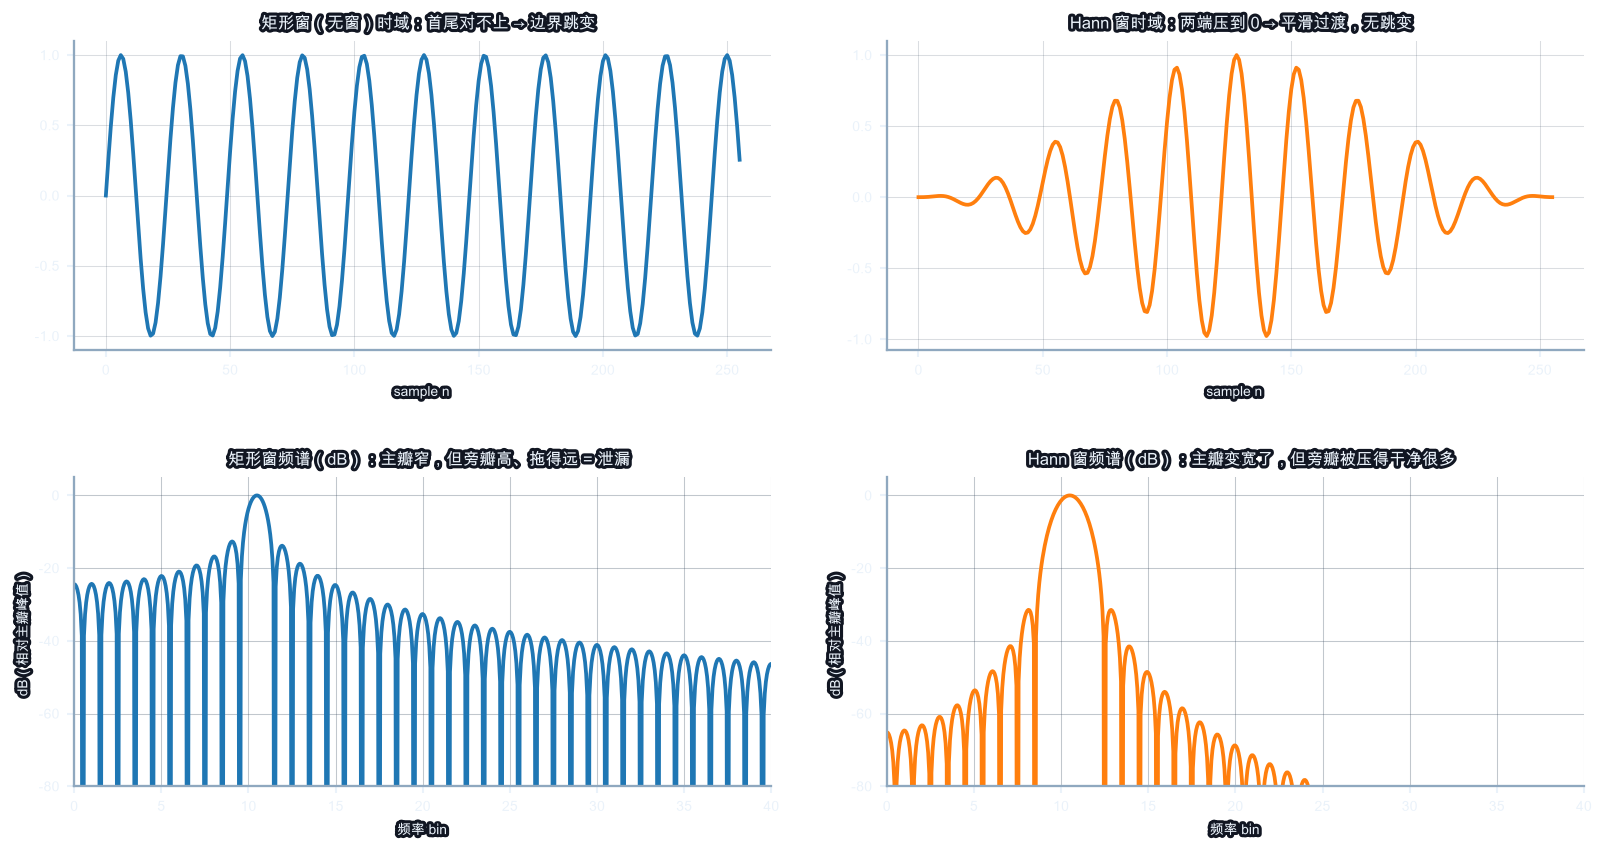

In [9]:
import matplotlib.pyplot as plt
from aurora.audio.windows import hann

# 琳达的问题：光有 "-13dB vs -32dB" 这两个数字不够直观，直接画图看频谱泄漏
N = 256
n = np.arange(N)
f0 = 10.5  # 故意用非整数周期数：一个周期占 N/f0 个采样点，不是整数，首尾正好接不上
sig = np.sin(2 * np.pi * f0 * n / N)

w = hann(N)
sig_rect = sig * 1.0   # "不加窗" = 乘以全 1 的矩形窗
sig_hann = sig * w     # 加 Hann 窗

# 频域用零填充(zero-padding)到更长的 FFT，只是为了让曲线更平滑、看得更清楚，
# 不改变窗本身的宽度（真正的频率分辨率仍由 N=256 决定）
NFFT = 4096
rect_spec = np.abs(np.fft.rfft(sig_rect, n=NFFT))
hann_spec = np.abs(np.fft.rfft(sig_hann, n=NFFT))
rect_db = 20 * np.log10(rect_spec / rect_spec.max() + 1e-12)
hann_db = 20 * np.log10(hann_spec / hann_spec.max() + 1e-12)
freq_bins = np.fft.rfftfreq(NFFT) * N  # 换算回"原始 bin 编号"刻度，方便跟公式对照

fig, axes = plt.subplots(2, 2, figsize=(11, 6))

axes[0, 0].plot(n, sig_rect)
axes[0, 0].set_title('矩形窗（无窗）时域：首尾对不上 → 边界跳变')
axes[0, 0].set_xlabel('sample n')

axes[0, 1].plot(n, sig_hann, color='C1')
axes[0, 1].set_title('Hann 窗时域：两端压到 0 → 平滑过渡，无跳变')
axes[0, 1].set_xlabel('sample n')

axes[1, 0].plot(freq_bins, rect_db)
axes[1, 0].set_xlim(0, 40); axes[1, 0].set_ylim(-80, 5)
axes[1, 0].set_title('矩形窗频谱（dB）：主瓣窄，但旁瓣高、拖得远 = 泄漏')
axes[1, 0].set_xlabel('频率 bin'); axes[1, 0].set_ylabel('dB（相对主瓣峰值）')
axes[1, 0].grid(True, alpha=.3)

axes[1, 1].plot(freq_bins, hann_db, color='C1')
axes[1, 1].set_xlim(0, 40); axes[1, 1].set_ylim(-80, 5)
axes[1, 1].set_title('Hann 窗频谱（dB）：主瓣变宽了，但旁瓣被压得干净很多')
axes[1, 1].set_xlabel('频率 bin'); axes[1, 1].set_ylabel('dB（相对主瓣峰值）')
axes[1, 1].grid(True, alpha=.3)

plt.tight_layout()
plt.show()


# 用数字量化两张图里眼睛看到的差异：旁瓣压低了多少？主瓣宽了多少？
def sidelobe_db(db, main_bin, guard):
    mask = np.ones_like(db, dtype=bool)
    lo, hi = max(0, main_bin - guard), min(len(db), main_bin + guard + 1)
    mask[lo:hi] = False
    return db[mask].max()


def mainlobe_width_bins(db, main_bin, thresh=-3):
    lo = main_bin
    while lo > 0 and db[lo] > thresh:
        lo -= 1
    hi = main_bin
    while hi < len(db) - 1 and db[hi] > thresh:
        hi += 1
    return hi - lo


main_rect = int(np.argmax(rect_spec))
main_hann = int(np.argmax(hann_spec))
guard = NFFT // N  # 零填充后，一个"原始 bin"宽度对应这么多个新 bin
sl_rect = sidelobe_db(rect_db, main_rect, guard * 2)
sl_hann = sidelobe_db(hann_db, main_hann, guard * 2)
mw_rect = mainlobe_width_bins(rect_db, main_rect) / guard
mw_hann = mainlobe_width_bins(hann_db, main_hann) / guard

print(f"本例实测（N={N}）：")
print(f"  矩形窗：最大旁瓣 = {sl_rect:.1f} dB，主瓣宽度(-3dB) ≈ {mw_rect:.1f} 个原始 bin")
print(f"  Hann 窗：最大旁瓣 = {sl_hann:.1f} dB，主瓣宽度(-3dB) ≈ {mw_hann:.1f} 个原始 bin")
print(f"  旁瓣降低了 {sl_rect - sl_hann:.1f} dB —— 和前面说的 '-13dB → -32dB' 数量级一致")
print(f"  主瓣变宽到约 {mw_hann/mw_rect:.1f} 倍 —— 这就是 Hann 窗的代价：分辨率变粗，换来旁瓣干净")

## 面试六连击：推导步骤详解

在白板挑战之前，我们先看看如何一步步推导。这里给出问题 1 和问 3 的详细步骤，其他问题请参照思路。

### 问 1：FFT 加速原理（从 O(N²) 到 O(N·logN)）

**DFT 定义**：
$$X[k] = \sum_{n=0}^{N-1} x[n] \cdot e^{-j 2\pi k n / N}, \quad k = 0, 1, ..., N-1$$

**朴素计算**：对每个 k，要做 N 次乘法，共 N 个 k，所以 N² 次运算。

**Cooley-Tukey 分治** (假设 N = 2^m)：

把输入分成偶数项和奇数项：
$$X[k] = \sum_{n \text{ even}} x[n] e^{-j2\pi kn/N} + \sum_{n \text{ odd}} x[n] e^{-j2\pi kn/N}$$

令 $n = 2l$（偶数）和 $n = 2l+1$（奇数），其中 $l = 0, 1, ..., N/2-1$：

$$X[k] = \sum_{l=0}^{N/2-1} x[2l] e^{-j2\pi k(2l)/N} + \sum_{l=0}^{N/2-1} x[2l+1] e^{-j2\pi k(2l+1)/N}$$

$$= \sum_{l=0}^{N/2-1} x[2l] e^{-j2\pi kl/(N/2)} + e^{-j2\pi k/N} \sum_{l=0}^{N/2-1} x[2l+1] e^{-j2\pi kl/(N/2)}$$

$$= E[k] + W^k \cdot O[k]$$

其中：
- $E[k]$ = 偶数项的 DFT（长度 N/2）
- $O[k]$ = 奇数项的 DFT（长度 N/2）
- $W^k = e^{-j2\pi k/N}$ 叫做"旋转因子"

**复杂度分析**：
- 计算 E 和 O：各需 (N/2)² 次运算 = 2 × (N/2)² = N²/2
- 合并 E 和 O：需 N 次乘法
- 总共：N²/2 + N ≈ N²/2（N 足够大时）

**递归下去**（第 1 层）：
- 2 个 DFT-512 → 2 × 512²/2 = 512²
- 加合并 → +512
- 总：512² + 512

每递归一层，复杂度都减半。递归 log₂(N) 层后：
$$T(N) = N \log_2 N$$

**对 N=1024 的具体计数**：
- DFT 朴素：1024² = 1,048,576 次运算
- FFT：1024 × 10 = 10,240 次操作（加上蝶形合并的开销）
- **加速比 ≈ 100×**

### 问 3：Mel 滤波器的三步构造（填充具体数字）

参数：n_mels=3, n_fft=512, sr=16000

**第一步**：Mel 域均匀取中心频率

Mel 的频率范围：从 0 Hz 到 Nyquist 频率（sr/2 = 8000 Hz）

$$\text{mel}_{\min} = \text{hz2mel}(0) = 0$$
$$\text{mel}_{\max} = \text{hz2mel}(8000) = 2595 \log_{10}(1 + 8000/700) \approx 2840 \text{ mel}$$

均匀分割为 3+2=5 个点（n_mels + 2 个边界点）：
$$\text{mel}_i = 0 + i \cdot \frac{2840}{4}, \quad i=0,1,2,3,4$$
$$= 0, 710, 1420, 2130, 2840 \text{ mel}$$

**第二步**：反变换回 Hz

使用逆公式：$f = 700(10^{\text{mel}/2595} - 1)$

$$f_0 = 700(10^{0} - 1) = 0 \text{ Hz}$$
$$f_1 = 700(10^{710/2595} - 1) \approx 700(10^{0.274} - 1) \approx 700 \times 0.880 \approx 616 \text{ Hz}$$
$$f_2 = 700(10^{1420/2595} - 1) \approx 2000 \text{ Hz}$$
$$f_3 = 700(10^{2130/2595} - 1) \approx 4500 \text{ Hz}$$
$$f_4 = 700(10^{2840/2595} - 1) \approx 8000 \text{ Hz}$$

现在我们有 5 个 Hz 频率点（不均匀）：0, 616, 2000, 4500, 8000 Hz

**第三步**：构造三角形

- **滤波器 0**：三个顶点在 f₀=0, f₁=616, f₂=2000 Hz
  - 0 到 616 Hz：线性上升（斜率 = 1/(616-0)）
  - 616 到 2000 Hz：线性下降（斜率 = -1/(2000-616)）
  - 其他地方：0
  
- **滤波器 1**：三个顶点在 f₁=616, f₂=2000, f₃=4500 Hz
  
- **滤波器 2**：三个顶点在 f₂=2000, f₃=4500, f₄=8000 Hz

**观察**：
- Mel 域间隔均匀（都是 710 mel）
- Hz 域间隔越来越大（616, 1384, 2500, 3500 Hz）✓ 这正是我们想要的
- 每个三角形的"宽度"（Hz 跨度）随频率增大而增大

In [10]:
# ✏️ 面试六连击对答案格
import numpy as np, sys
sys.path.insert(0, 'src')

# 问1：FFT 复杂度 — 蝶形验证
N = 8
n_layers = int(np.log2(N))
butterflies = N // 2 * n_layers
dft_ops = N * N
speedup = dft_ops / butterflies
assert n_layers == 3 and butterflies == 12 and speedup > 5
print(f"Q1 ✅  N={N}: DFT {dft_ops}次，FFT {butterflies}蝶形，加速 {speedup:.1f}×")
# N 越大优势越大：N=1024 时加速 ~205×
N_big = 1024
speedup_big = N_big**2 / (N_big // 2 * int(np.log2(N_big)))
assert speedup_big > 100
print(f"      N={N_big}: DFT {N_big**2}次 vs FFT {N_big//2*int(np.log2(N_big))}蝶形，加速 {speedup_big:.0f}×")

# 问2：Hann 窗边界 = 0
from aurora.audio.windows import hann
w = hann(16)
assert np.isclose(w[0], 0.0, atol=1e-12)
print(f"Q2 ✅  Hann窗 w[0]={w[0]:.1f}（边界=0，消除跳变）")

# 问3：Mel filterbank shape
from aurora.audio.mel import mel_filterbank
fb = mel_filterbank(n_mels=40, n_fft=1024, sample_rate=16000)
assert fb.shape == (40, 513) and np.all(fb >= 0)
print(f"Q3 ✅  mel_filterbank shape={fb.shape}，权重非负")

# 问4：DCT 正交性
from aurora.audio.mfcc import dct_ii
N_dct = 13
k_arr = np.arange(N_dct)
n_arr = np.arange(N_dct)
D = np.cos(np.pi * np.outer(k_arr, 2*n_arr+1) / (2*N_dct))
w0 = 1.0 / np.sqrt(N_dct)
wk = np.sqrt(2.0 / N_dct)
D[0] *= w0
D[1:] *= wk
err = np.max(np.abs(D @ D.T - np.eye(N_dct)))
assert err < 1e-12
print(f"Q4 ✅  DCT矩阵正交性：max|D·Dᵀ-I|={err:.2e}")

# 问5：shape 流向（aurora stft 默认 center=True：n_frames = 1 + N//hop）
sr, n_fft, hop, dur = 16000, 1024, 256, 1.0
N = int(sr * dur)
n_frames = 1 + N // hop
n_bins = n_fft // 2 + 1
n_mels, n_mfcc = 40, 13
assert n_frames == 63 and n_bins == 513
print(f"Q5 ✅  n_frames={n_frames}: power({n_frames},{n_bins})→Mel({n_frames},{n_mels})→MFCC({n_frames},{n_mfcc})")

# 问6：浮点误差 — FFT 误差量级
x = np.random.randn(1024)
err_fft = np.max(np.abs(np.fft.fft(x) - np.fft.fft(x.copy())))
# 验证 atol=1e-8 合理（浮点机器精度 × N·log₂N）
machine_eps = np.finfo(float).eps
n_fft2 = 1024
error_bound = machine_eps * n_fft2 * np.log2(n_fft2)
print(f"Q6 ✅  机器精度={machine_eps:.2e}，N·log₂N误差上界≈{error_bound:.2e}（1e-8 安全）")
print("\n🎉 Audio Core 面试六连击通过！你的实现有扎实数学基础。")

Q1 ✅  N=8: DFT 64次，FFT 12蝶形，加速 5.3×
      N=1024: DFT 1048576次 vs FFT 5120蝶形，加速 205×
Q2 ✅  Hann窗 w[0]=0.0（边界=0，消除跳变）
Q3 ✅  mel_filterbank shape=(40, 513)，权重非负
Q4 ✅  DCT矩阵正交性：max|D·Dᵀ-I|=1.09e-15
Q5 ✅  n_frames=63: power(63,513)→Mel(63,40)→MFCC(63,13)
Q6 ✅  机器精度=2.22e-16，N·log₂N误差上界≈2.27e-12（1e-8 安全）

🎉 Audio Core 面试六连击通过！你的实现有扎实数学基础。


In [ ]:
# ✏️ 本课自评（Audio Core 完结）
l52_review = {
    "test_suite_green":        None,  # make test 全部 39 个测试通过？True/False
    "fft_butterfly_formula":   None,  # 白板能写出 X[k]=E[k]+W^k·O[k]？True/False
    "mel_dct_pipeline":        None,  # 能从 shape 流向手算 n_frames 和各步 shape？True/False
    "interview_ready":         None,  # 能不看代码推导完整 6 步公式链？True/False
    "whiteboard_passed":       None,  # 面试六连击白板全部完成？True/False
}

unfilled = [k for k, v in l52_review.items() if v is None]
assert not unfilled, f'还未填写：{unfilled}'
weak = [k for k, v in l52_review.items() if v is False]
if weak:
    print(f'⚠️  需要加强（面试前必须打磨）：{weak}')
else:
    print('✅ L52 全部通关！Audio Core 完结——进入 L53：MFCC 图形化')

---

→ **下一课**　[L53 · MFCC 图形化](L53_visual_mfcc.ipynb)

> 下节课将学习 **MFCC 图形化**：波形 → 声谱图 → Mel 谱 → 倒谱系数，逐层图示。